In [202]:
#Loading in Packages and Data

#Importing Packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import xarray as xr
import os; import time
import pickle
import h5py
###############################################################
def coefs(coefficients,degree):
    coef=coefficients
    coefs=""
    for n in range(degree, -1, -1):
        string=f"({coefficients[len(coef)-(n+1)]:.1e})"
        coefs+=string + f"x^{n}"
        if n != 0:
            coefs+=" + "
    return coefs
###############################################################

# Importing Model Data
check=False
dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'

# # dx = 1 km; Np = 1M; Nt = 5 min
# data=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_1km_5min.nc') #***
# parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_1km_5min_1e6.nc') #***
# res='1km';t_res='5min'
# Np_str='1e6'

# # dx = 1km; Np = 50M
# #Importing Model Data
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_1km_1min.nc') #***
# parcel=xr.open_dataset(dir2+'cm1out_pdata_1km_1min_50M.nc') #***
# res='1km'; t_res='1min'; Np_str='50e6'

# dx = 1km; Np = 50M; Nz = 95
#Importing Model Data
dir2='/home/air673/koa_scratch/'
data=xr.open_dataset(dir2+'cm1out_1km_1min_95nz.nc') #***
parcel=xr.open_dataset(dir2+'cm1out_pdata_1km_1min_95nz.nc') #***
res='1km'; t_res='1min_95nz'; Np_str='50e6'

In [203]:
times=data['time'].values/(1e9 * 60); times=times.astype(float);
minutes=1/times[1] #1 / minutes per timestep = timesteps per minute
job_array=False;index_adjust=0
ocean_fraction=2/8

In [204]:
import sys
dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
path=dir2+'../Functions/'
sys.path.append(path)

import NumericalFunctions
from NumericalFunctions import * # import NumericalFunctions 
import PlottingFunctions
from PlottingFunctions import * # import PlottingFunctions

# # Get all functions in NumericalFunctions
# import inspect
# functions = [f[0] for f in inspect.getmembers(NumericalFunctions, inspect.isfunction)]
# functions

#####

#Import StatisticalFunctions 
import sys
dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
path=dir2+'../Functions/'
sys.path.append(path)

import StatisticalFunctions
from StatisticalFunctions import * # import NumericalFunctions 

In [205]:
#CL VS NONCL
################################################################

In [206]:
##########################################################
#PLOTTING

In [207]:
#LIMITING Y AXIS
limit_y=True
limit_y=False

In [208]:
def limit_axes_to_y(ax, y_min=0, y_max=7, buffer_frac=0.1):
    ax.set_ylim(y_min, y_max)

    x_limited = []

    # Handle lines (from ax.plot)
    for line in ax.get_lines():
        xdata, ydata = np.array(line.get_xdata()), np.array(line.get_ydata())
        y_mask = (ydata >= y_min) & (ydata <= y_max)
        x_visible = xdata[y_mask]
        x_visible = x_visible[np.isfinite(x_visible)]
        x_limited.extend(x_visible)

    # Handle fill_betweenx (PolyCollection)
    for collection in ax.collections:
        try:
            paths = collection.get_paths()
            for path in paths:
                verts = path.vertices  # Nx2 array of (x, y)
                xdata, ydata = verts[:, 0], verts[:, 1]
                y_mask = (ydata >= y_min) & (ydata <= y_max)
                x_visible = xdata[y_mask]
                x_visible = x_visible[np.isfinite(x_visible)]
                x_limited.extend(x_visible)
        except Exception as e:
            print("Warning: failed to process collection:", e)

    if len(x_limited) > 0:
        x_limited = np.array(x_limited)
        x_min, x_max = np.min(x_limited), np.max(x_limited)

        if not (np.isfinite(x_min) and np.isfinite(x_max)):
            print("Warning: Non-finite x-limits detected, skipping set_xlim")
            return

        x_range = x_max - x_min
        buffer = buffer_frac * x_range if x_range > 0 else 0.1
        ax.set_xlim(x_min - buffer, x_max + buffer)
    else:
        print("Warning: No visible x data within y limits to set xlim")


In [209]:
def averaged_profiles(profile):
    out_var = profile[(profile[:, 1] > 1)]  # gets rid of rows that have no data
    out_var = np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T  # divides the data column by the counter column
    return out_var

In [210]:
def LoadAllCloudBase():
    dir2 = dir + f'Project_Algorithms/Tracking_Algorithms/'
    in_file = dir2 + f"all_cloudbase_{res}_{t_res}_{Np_str}.pkl"
    with open(in_file, 'rb') as f:
        all_cloudbase = pickle.load(f)
    return(all_cloudbase)
min_all_cloudbase=np.nanmin(LoadAllCloudBase())
all_cloudbase=min_all_cloudbase
print(f"Minimum Cloudbase is: {all_cloudbase}\n")

Minimum Cloudbase is: 1.225000023841858



In [211]:
def LoadMeanLFC():
    dir2 = dir + f'Project_Algorithms/Tracking_Algorithms/'
    in_file = dir2 + f"MeanLFC_{res}_{t_res}_{Np_str}.pkl"
    with open(in_file, 'rb') as f:
        MeanLFC = pickle.load(f)
    return MeanLFC
MeanLFC=LoadMeanLFC()
print(f"Mean LFC is: {MeanLFC}\n")

Mean LFC is: 1856.2518881791163



In [212]:
def PlotSE(ax, profile, SE_profile, color, factor, switch=1, alpha=0.1, min_value=None):
    lower = profile[:, 0] - factor * SE_profile[:, 0] * switch
    upper = profile[:, 0] + factor * SE_profile[:, 0] * switch
    if min_value is not None:
        lower = np.maximum(lower, min_value)
    ax.fill_betweenx(profile[:, -1], lower, upper, color=color, alpha=alpha)
    #Example #PlotSE(ax,ALL_profile,ALL_SE_array,color=color,factor=factor, min_value=min_value)

def PlotProfiles(ax,type1,type2,type3,type4):
    if type3!="NET":
        min_value=0
    else:
        min_value=None
    lw = 0.8
    
    # cutoff_height = 100 #doesn't do anything since ztop is much less than 100
    # z_cutoff = np.where(globals()[f"{type1}_ALL_profile_array_{type3}_{type4}"][:, 2] <= cutoff_height)[0][-1]

    profiles = [
        (globals()[f"{type1}_ALL_profile_array_{type3}_{type4}"], globals()[f"{type1}_SHALLOW_profile_array_{type3}_{type4}"], globals()[f"{type1}_DEEP_profile_array_{type3}_{type4}"], type1),
        (globals()[f"{type2}_ALL_profile_array_{type3}_{type4}"], globals()[f"{type2}_SHALLOW_profile_array_{type3}_{type4}"], globals()[f"{type2}_DEEP_profile_array_{type3}_{type4}"], type2)
    ]

    SE_profiles = [
        (globals()[f"{type1}_ALL_profile_array_{type3}_{type4}_SE"], globals()[f"{type1}_SHALLOW_profile_array_{type3}_{type4}_SE"], globals()[f"{type1}_DEEP_profile_array_{type3}_{type4}_SE"], type1),
        (globals()[f"{type2}_ALL_profile_array_{type3}_{type4}_SE"], globals()[f"{type2}_SHALLOW_profile_array_{type3}_{type4}_SE"], globals()[f"{type2}_DEEP_profile_array_{type3}_{type4}_SE"], type2)
    ]
    

    for ((ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, label),
     (ALL_SE_array, SHALLOW_SE_array, DEEP_SE_array, _)) in zip(profiles, SE_profiles):

        # ALL_profile = averaged_profiles(ALL_profile_array)[:z_cutoff]
        # SHALLOW_profile = averaged_profiles(SHALLOW_profile_array)[:z_cutoff]
        # DEEP_profile = averaged_profiles(DEEP_profile_array)[:z_cutoff]
        ALL_profile = averaged_profiles(ALL_profile_array)
        SHALLOW_profile = averaged_profiles(SHALLOW_profile_array)
        DEEP_profile = averaged_profiles(DEEP_profile_array)

        if label == type1:
            ax.plot(ALL_profile[:, 0], ALL_profile[:, -1], linestyle='solid',color='black', label=f'ALL ({type1})', lw=lw)
            PlotSE(ax,ALL_profile,ALL_SE_array,color='black',factor=factor, min_value=min_value)
            ax.plot(SHALLOW_profile[:, 0], SHALLOW_profile[:, -1], linestyle='solid', color='green', label=f'SHALLOW ({type1})', lw=lw)
            PlotSE(ax,SHALLOW_profile,SHALLOW_SE_array,color='green',factor=factor, min_value=min_value)
            ax.plot(DEEP_profile[:, 0], DEEP_profile[:, -1], linestyle='solid',color='blue', label=f'DEEP ({type1})', lw=lw)
            PlotSE(ax,DEEP_profile,DEEP_SE_array,color='blue',factor=factor, min_value=min_value)
        else:
            ax.plot(ALL_profile[:, 0], ALL_profile[:, -1], linestyle='dashed', color='black', label=f'ALL ({type2})', lw=lw)
            PlotSE(ax,ALL_profile,ALL_SE_array,color='black',factor=factor, min_value=min_value)
            ax.plot(SHALLOW_profile[:, 0], SHALLOW_profile[:, -1], linestyle='dashed', color='green', label=f'SHALLOW ({type2})', lw=lw)
            PlotSE(ax,SHALLOW_profile,SHALLOW_SE_array,color='green',factor=factor, min_value=min_value)
            ax.plot(DEEP_profile[:, 0], DEEP_profile[:, -1], linestyle='dashed', color='blue', label=f'DEEP ({type2})', lw=lw)
            PlotSE(ax,DEEP_profile,DEEP_SE_array,color='blue',factor=factor, min_value=min_value)

        apply_scientific_notation([ax])

    ax.set_xlabel(r"($kg m^{-3} s^{-1}$)")  
    ax.set_ylabel('z (km)')
    ax.grid(True)
    ax.axvline(0, linestyle='dashed', color='grey', zorder=-10)
    ax.axhline(all_cloudbase, color='purple', linestyle='dashed')
    ax.axhline(MeanLFC/1000,color='green',linestyle='dashed')
    ax.legend(fontsize=8)

def PlotTwo(ax, type1, type2, factor=1):
    min_value=0
    lw = 0.8
    
    # cutoff_height = 100 #doesn't do anything since ztop is much less than 100 
    # z_cutoff = np.where(CL_ALL_profile_array_G_TO_C[:, 2] <= cutoff_height)[0][-1]

    # Define profile arrays
    profiles = [
        (CL_ALL_profile_array_G_TO_C, CL_SHALLOW_profile_array_G_TO_C, CL_DEEP_profile_array_G_TO_C, type1),
        (nonCL_ALL_profile_array_G_TO_C, nonCL_SHALLOW_profile_array_G_TO_C, nonCL_DEEP_profile_array_G_TO_C, type2)
    ]

    # Define standard error arrays
    SE_profiles = [
        (CL_ALL_profile_array_G_TO_C_SE, CL_SHALLOW_profile_array_G_TO_C_SE, CL_DEEP_profile_array_G_TO_C_SE, type1),
        (nonCL_ALL_profile_array_G_TO_C_SE, nonCL_SHALLOW_profile_array_G_TO_C_SE, nonCL_DEEP_profile_array_G_TO_C_SE, type2)
    ]

    for ((ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, label),
         (ALL_SE_array, SHALLOW_SE_array, DEEP_SE_array, _)) in zip(profiles, SE_profiles):

        # ALL_profile = averaged_profiles(ALL_profile_array)[:z_cutoff]
        # SHALLOW_profile = averaged_profiles(SHALLOW_profile_array)[:z_cutoff]
        # DEEP_profile = averaged_profiles(DEEP_profile_array)[:z_cutoff]
        ALL_profile = averaged_profiles(ALL_profile_array)
        SHALLOW_profile = averaged_profiles(SHALLOW_profile_array)
        DEEP_profile = averaged_profiles(DEEP_profile_array)

        linestyle = 'solid' if label == type1 else 'dashed'

        ax.plot(ALL_profile[:, 0], ALL_profile[:, -1], linestyle=linestyle, color='black', label=f'ALL ({label})', lw=lw)
        PlotSE(ax, ALL_profile, ALL_SE_array, color='black', factor=factor, min_value=min_value)

        ax.plot(SHALLOW_profile[:, 0], SHALLOW_profile[:, -1], linestyle=linestyle, color='green', label=f'SHALLOW ({label})', lw=lw)
        PlotSE(ax, SHALLOW_profile, SHALLOW_SE_array, color='green', factor=factor, min_value=min_value)

        ax.plot(DEEP_profile[:, 0], DEEP_profile[:, -1], linestyle=linestyle, color='blue', label=f'DEEP ({label})', lw=lw)
        PlotSE(ax, DEEP_profile, DEEP_SE_array, color='blue', factor=factor, min_value=min_value)

        apply_scientific_notation([ax])

    # Final plot settings
    ax.set_xlabel(r"($kg m^{-3} s^{-1}$)")  
    ax.set_ylabel('z (km)')
    ax.grid(True)
    ax.axvline(0, linestyle='dashed', color='grey', zorder=-10)
    ax.axhline(all_cloudbase, color='purple', linestyle='dashed')
    ax.axhline(MeanLFC/1000,color='green',linestyle='dashed')
    ax.legend(fontsize=8)
    plt.tight_layout()

    return ax

In [213]:
def safe_divide(numerator, denominator):
    # result=numerator/denominator
    # Convert to numpy arrays for safety
    numerator = np.array(numerator)
    denominator = np.array(denominator)
    
    # Mask denominator zeros or very small values to avoid divide-by-zero
    mask = (denominator == 0) | np.isnan(denominator) | np.isnan(numerator)
    
    # Create a result array filled with NaNs initially
    result = np.full_like(numerator, np.nan, dtype=float)
    
    # Only divide where denominator is nonzero and both numerator/denominator are finite
    valid = ~mask
    result[valid] = numerator[valid] / denominator[valid]
    
    return result


def RatioPlot(ax, type1, type2, type3, type4, factor=1):
    lw = 0.8
    cutoff_height = 100

    # Determine cutoff index from one profile (assuming CL_ALL_profile_array_G_TO_C is available)
    z_cutoff = np.where(CL_ALL_profile_array_G_TO_C[:, 2] <= cutoff_height)[0][-1]; z_cutoff=None #*#*#*

    # Environment (reference) profiles to divide by
    profiles1 = [
        (globals()[f"{type1}_ALL_profile_array_G_TO_C"],
         globals()[f"{type1}_SHALLOW_profile_array_G_TO_C"],
         globals()[f"{type1}_DEEP_profile_array_G_TO_C"],
         type1),
        (globals()[f"{type2}_ALL_profile_array_G_TO_C"],
         globals()[f"{type2}_SHALLOW_profile_array_G_TO_C"],
         globals()[f"{type2}_DEEP_profile_array_G_TO_C"],
         type2)
    ]

    # Environment (reference) profiles to divide by
    profiles2 = [
        (globals()[f"{type1}_ALL_profile_array_{type3}_{type4}"],
         globals()[f"{type1}_SHALLOW_profile_array_{type3}_{type4}"],
         globals()[f"{type1}_DEEP_profile_array_{type3}_{type4}"],
         type1),
        (globals()[f"{type2}_ALL_profile_array_{type3}_{type4}"],
         globals()[f"{type2}_SHALLOW_profile_array_{type3}_{type4}"],
         globals()[f"{type2}_DEEP_profile_array_{type3}_{type4}"],
         type2)
    ]

    # Iterate cleanly over paired profiles
    for (prof1_all, prof1_sh, prof1_dp, label1), (prof2_all, prof2_sh, prof2_dp, label2) in zip(profiles1, profiles2):

        linestyle = 'solid' if label1 == type1 else 'dashed'

        # Compute averaged and truncated profiles
        prof1_all_avg = averaged_profiles(prof1_all)[:z_cutoff]
        prof1_sh_avg  = averaged_profiles(prof1_sh)[:z_cutoff]
        prof1_dp_avg  = averaged_profiles(prof1_dp)[:z_cutoff]

        prof2_all_avg = averaged_profiles(prof2_all)[:z_cutoff]
        prof2_sh_avg  = averaged_profiles(prof2_sh)[:z_cutoff]
        prof2_dp_avg  = averaged_profiles(prof2_dp)[:z_cutoff]

        # Compute and plot ratios
        ax.plot(safe_divide(prof1_all_avg[:, 0], prof2_all_avg[:, 0]), prof1_all_avg[:, -1],
                linestyle=linestyle, color='black', label=f'ALL ({label1})', lw=lw)

        ax.plot(safe_divide(prof1_sh_avg[:, 0] , prof2_sh_avg[:, 0]), prof1_sh_avg[:, -1],
                linestyle=linestyle, color='green', label=f'SHALLOW ({label1})', lw=lw)

        ax.plot(safe_divide(prof1_dp_avg[:, 0] , prof2_dp_avg[:, 0]), prof1_dp_avg[:, -1],
                linestyle=linestyle, color='blue', label=f'DEEP ({label1})', lw=lw)

    apply_scientific_notation([ax])

    # Final plot settings
    ax.set_xlim(0-0.05, 1+0.05)
    ax.set_xlabel(r"($kg m^{-3} s^{-1}$)")  
    ax.set_ylabel('z (km)')
    ax.grid(True)
    ax.axvline(0, linestyle='dashed', color='grey', zorder=-10)
    ax.axvline(1, linestyle='dashed', color='grey', zorder=-10)
    ax.axhline(all_cloudbase, color='purple', linestyle='dashed')
    ax.axhline(MeanLFC/1000,color='green',linestyle='dashed')
    ax.legend(fontsize=8)
    plt.tight_layout()

    return ax


In [214]:
#DIFFERENCE PLOT
def average_difference(array1, array2):
    out_var_one=averaged_profiles(array1)
    out_var_two=averaged_profiles(array2)

    #masking out non matches
    second_col_one = out_var_one[:, 1]
    second_col_two = out_var_two[:, 1]
    mask_one = np.isin(second_col_one, second_col_two)
    mask_two = np.isin(second_col_two, second_col_one)
    
    out_var_one = out_var_one.copy()[mask_one]
    out_var_two = out_var_two.copy()[mask_two]
    
    diff=(out_var_one[:,0]-out_var_two[:,0])
    zs=out_var_one[:,1]

    out_profile=np.zeros((len(diff),2))

    out_profile[:,0]=diff;out_profile[:,1]=zs;
    return out_profile

In [215]:
#DIFFERENCE PLOT
def compute_diff1(group1, group2, cat, type1, var='NET'):
    profile1 = globals()[f"{group1}_{cat}_profile_array_{var}_{type1}"]
    profile2 = globals()[f"{group2}_{cat}_profile_array_{var}_{type1}"]
    globals()[f"{group1}_{group2}_{cat}_diff_{var.lower()}"] = average_difference(profile1, profile2)
    # print(f"{group1}_{group2}_{cat}_diff_{var.lower()}")

def PlotDifference1(group1,group2,type1):
    ######################
    #Calculating
    # group1='CL';group2='nonCL'
    cats=['ALL','SHALLOW','DEEP']
    for cat in cats:
        compute_diff1(group1,group2,cat,type1[0].upper())

    ######################
    #Plotting
    lw=1
    
    # List of profile arrays and their corresponding labels and x-axis titles
    profiles = [
        (globals()[f"{group1}_{group2}_ALL_diff_net"],  'net', 'ALL','black'),
        (globals()[f"{group1}_{group2}_SHALLOW_diff_net"],  'net', 'SHALLOW','green'),
        (globals()[f"{group1}_{group2}_DEEP_diff_net"],  'net', 'DEEP','blue')
    ]
    
    # Set up the figure
    fig = plt.figure(figsize=(8, 6))
    
    # Create a single axis for all profiles
    ax = fig.add_subplot(111)
    
    # Loop through profiles for CL and nonCL
    for i, (profile, xlabel, CLlabel,color) in enumerate(profiles):
    
        #CUT BELOW CERTAIN Z
        ax.plot(profile[:, 0], profile[:, -1], color=color, label=CLlabel,lw=lw)
        apply_scientific_notation([ax])
    
    
    # Add labels and title
    ax.set_xlabel(r"($kg m^{-3} s^{-1}$)")
    ax.set_ylabel('z (km)')
    ax.grid(True)
    
    ax.axvline(0,linestyle='dashed',color='grey',zorder=-10)
    
    # Show legend
    ax.legend()
    
    #MEAN CLOUD BASE
    ax.axhline(all_cloudbase,color='purple',linestyle='dashed',lw=1)
    ax.axhline(MeanLFC/1e3,color='green',linestyle='dashed',lw=1)

    #FIX YLIMIT
    ax.set_ylim(bottom=0)
    #LIMITING YAXIS TO BELOW 7 KM
    if type4=='general':
        y_max=4
    else:
        y_max=7
    if limit_y==True: 
        ax.set_ylim(bottom=0,top=y_max)
    
    # Set up the main title and adjust layout
    plt.suptitle(f'({group1} vs {group2}) Vertical Profiles for \n Updraft Net {type1[0].upper()+type1[1:]} Entrainment from Tracked Lagrangian Parcels')
    plt.tight_layout()


In [216]:
#DIFFERENCE PLOT
def compute_diff2(group, cat1, cat2, type1, var='NET'):
    profile1 = globals()[f"{group}_{cat1}_profile_array_{var}_{type1}"]
    profile2 = globals()[f"{group}_{cat2}_profile_array_{var}_{type1}"]
    globals()[f"{group}_{cat1}_{cat2}_diff_{var.lower()}"] = average_difference(profile1, profile2)
    # print(f"{group1}_{group2}_{cat}_diff_{var.lower()}")

def PlotDifference2(group1,group2,cat1,cat2,type1):
    ######################
    #Calculating
    cat1='DEEP';cat2='SHALLOW'
    groups=[group1,group2]
    for group in groups:
        compute_diff2(group,cat1,cat2,type1[0].upper())

    ######################
    #Plotting
    lw=1
    
    # List of profile arrays and their corresponding labels and x-axis titles
    profiles = [
        (globals()[f"{group1}_{cat1}_{cat2}_diff_net"],  'net', f'{group1}','black','solid'),
        (globals()[f"{group2}_{cat1}_{cat2}_diff_net"],  'net', f'{group2}','black','dashed')
    ]
    
    # Set up the figure
    fig = plt.figure(figsize=(8, 6))
    
    # Create a single axis for all profiles
    ax = fig.add_subplot(111)
    
    # Loop through profiles for CL and nonCL
    for i, (profile, xlabel, CLlabel,color,linestyle) in enumerate(profiles):
    
        #CUT BELOW CERTAIN Z
        ax.plot(profile[:, 0], profile[:, -1], color=color, label=CLlabel,linestyle=linestyle,lw=lw)
        apply_scientific_notation([ax])
    
    
    # Add labels and title
    ax.set_xlabel(r"($kg m^{-3} s^{-1}$)")
    ax.set_ylabel('z (km)')
    ax.grid(True)
    
    ax.axvline(0,linestyle='dashed',color='grey',zorder=-10)
    
    # Show legend
    ax.legend()
    
    #MEAN CLOUD BASE
    ax.axhline(all_cloudbase,color='purple',linestyle='dashed',lw=1)
    ax.axhline(MeanLFC/1e3,color='green',linestyle='dashed',lw=1)

    #FIX YLIMIT
    ax.set_ylim(bottom=0)
    #LIMITING YAXIS TO BELOW 7 KM
    if type4=='general':
        y_max=4
    else:
        y_max=7
    if limit_y==True: 
        ax.set_ylim(bottom=0,top=y_max)
    
    # Set up the main title and adjust layout
    plt.suptitle(f'({cat1} minus {cat2}) Vertical Profiles for \n Updraft Net {type1[0].upper()+type1[1:]} Entrainment from Tracked Lagrangian Parcels')
    plt.tight_layout()


In [217]:
############################################################
#PLOTTING

In [218]:
PROCESSING=False
PROCESSING=True

In [219]:
data_type="Tracked_Entrainment_VMF"
type1='CL';type2='nonCL'
dir3=dir+'Project_Algorithms/Tracked_Profiles/OUTPUT_FILES/'
if PROCESSING==True:
    filePath=dir3+f"{data_type}_"+f"{type1}_{type2}_tracked_profiles_{res}_{t_res}_{Np_str}.h5"
elif PROCESSING==False:
    filePath=dir3+f"{data_type}_"+f"{type1}_{type2}_tracked_profiles_{res}_{t_res}_{Np_str}_ORIGINAL.h5"
key_list=[]
with h5py.File(filePath, 'r') as h5f:
    for key in h5f.keys():
        globals()[key] = h5f[key][:]
        if '_squares' not in key:
            key_list.append(key)

#CALCULATING STANDARD DEVIATION
for key in key_list:
    # globals()[key+f"_SE"]=ProfileStandardError(globals()[key],globals()[key+f"_squares"]);factor=1.96
    globals()[key+f"_SE"]=ProfileStandardDeviation(globals()[key],globals()[key+f"_squares"]); factor=1
    # print(key)

In [220]:
data_type2="Tracked_Combined_Entrainment"
type1='CL';type2='nonCL'
dir3=dir+'Project_Algorithms/Tracked_Profiles/OUTPUT_FILES/'
if PROCESSING==True:
    filePath=dir3 + f"{data_type2}_" + f"{type1}_{type2}_tracked_profiles_{res}_{t_res}_{Np_str}.h5"
elif PROCESSING==False:
    filePath=dir3 + f"{data_type2}_" + f"{type1}_{type2}_tracked_profiles_{res}_{t_res}_{Np_str}_ORIGINAL.h5"
key_list=[]
with h5py.File(filePath, 'r') as h5f:
    for key in h5f.keys():
        globals()[key] = h5f[key][:]
        if '_squares' not in key:
            key_list.append(key)
        # print(key)

#CALCULATING STANDARD DEVIATION
for key in key_list:
    # globals()[key+f"_SE"]=ProfileStandardError(globals()[key],globals()[key+f"_squares"]);factor=1.96
    globals()[key+f"_SE"]=ProfileStandardDeviation(globals()[key],globals()[key+f"_squares"]); factor=1

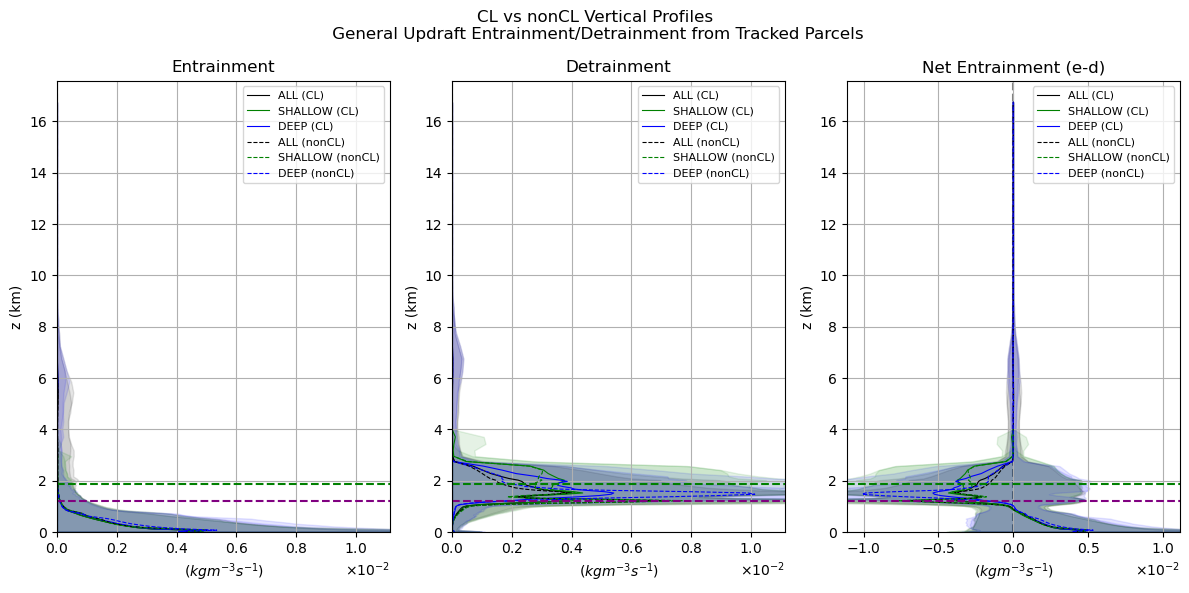

In [221]:
#PLOTTING
type4='general'
# type4='cloudy'

fig = plt.figure(figsize=(12, 6))
gs = fig.add_gridspec(1, 3)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])

# Run the plotting function separately for each axis
PlotProfiles(ax1,type1=type1,type2=type2,type3='E',type4=type4[0].upper())
PlotProfiles(ax2,type1=type1,type2=type2,type3='D',type4=type4[0].upper())
PlotProfiles(ax3,type1=type1,type2=type2,type3='NET',type4=type4[0].upper())

#LIMITING Y AXIS
if type4=='general':
    y_max=4
else:
    y_max=7
for ax in [ax1,ax2,ax3]:
    ax.set_ylim(bottom=0)
    #LIMITING YAXIS TO BELOW 7 KM
    if limit_y==True: 
        limit_axes_to_y(ax,y_min=0, y_max=y_max)    
MatchAxisLimits([ax1,ax2,ax3],dim='x')
for ax in [ax1,ax2]:
    ax.set_xlim(left=0)

# Optional: customize titles for each panel
ax1.set_title('Entrainment');ax1.set_ylim(bottom=0)
ax2.set_title('Detrainment');ax2.set_ylim(bottom=0)
ax3.set_title('Net Entrainment (e-d)');ax3.set_ylim(bottom=0)

plt.suptitle(f'{type1} vs {type2} Vertical Profiles\n {type4.title()} Updraft Entrainment/Detrainment from Tracked Parcels')
plt.tight_layout()


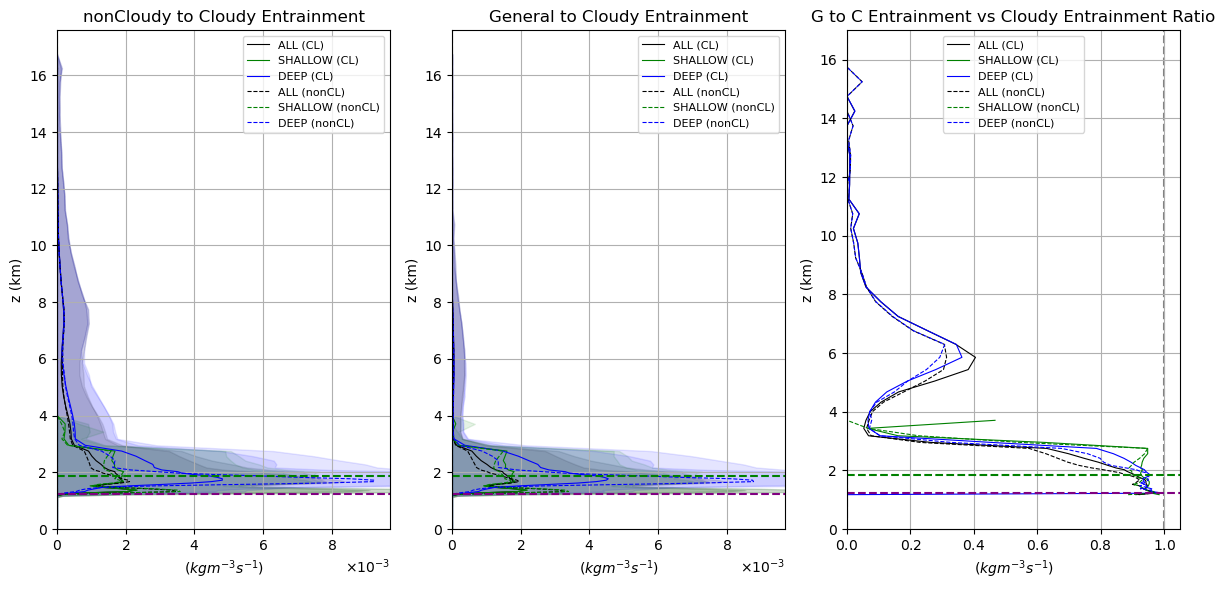

In [222]:
#PLOTTING
type4='cloudy'

fig = plt.figure(figsize=(12, 6))
gs = fig.add_gridspec(1,3)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])

# Run the plotting function separately for each axis
PlotProfiles(ax1,type1=type1,type2=type2,type3='E',type4=type4[0].upper())
PlotTwo(ax2,type1=type1,type2=type2)
RatioPlot(ax3,type1=type1,type2=type2,type3='E',type4=type4[0].upper())

#LIMITING Y AXIS
for ax in [ax1,ax2,ax3]:
    ax.set_ylim(bottom=0)
    #LIMITING YAXIS TO BELOW 7 KM
    if limit_y==True: 
        limit_axes_to_y(ax,y_min=0, y_max=7)
MatchAxisLimits([ax1,ax2],dim='x')
for ax in [ax1,ax2,ax3]:
    ax.set_xlim(left=0)


# Optional: customize titles for each panel
ax1.set_title('nonCloudy to Cloudy Entrainment')
ax2.set_title('General to Cloudy Entrainment')
ax3.set_title('G to C Entrainment vs Cloudy Entrainment Ratio')
plt.tight_layout()

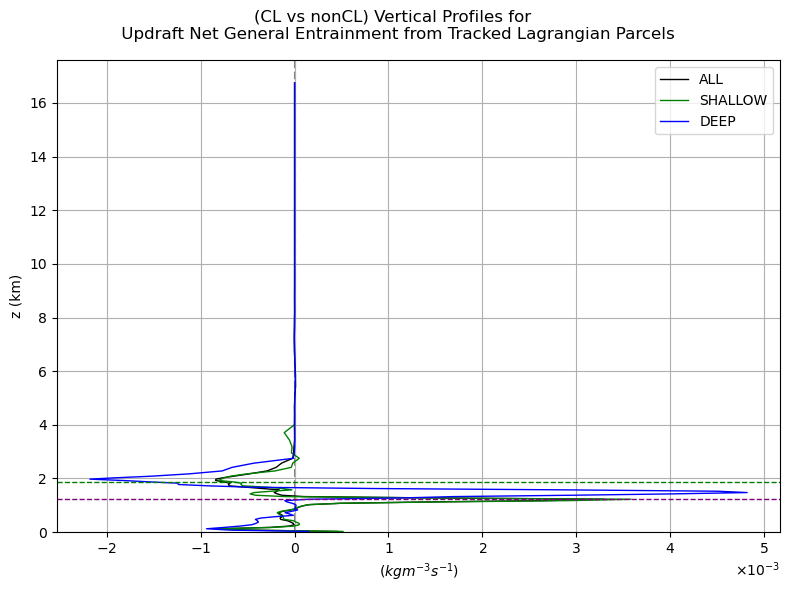

In [223]:
#DIFFERENCE PLOT
type4='general'
# type4='cloudy'

group1='CL';group2='nonCL'
PlotDifference1(group1,group2,type4)

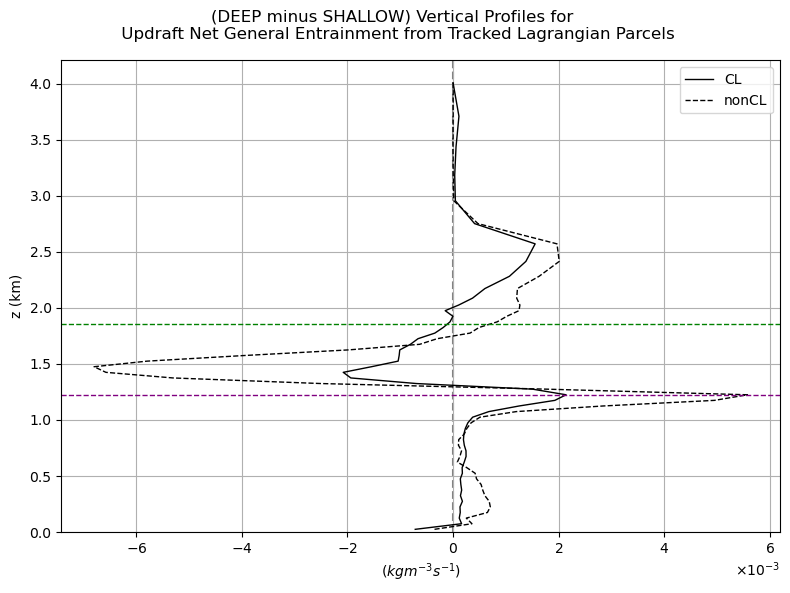

In [224]:
#DIFFERENCE PLOT
type4='general'
# type4='cloudy'

cat1='DEEP';cat2='SHALLOW'
group1='CL';group2='nonCL'
PlotDifference2(group1,group2,cat1,cat2,type4)

In [225]:
##########################################################################################
#SBZ vs nonSBZ Tracked Entrainment Profiles

In [226]:
##########################################################
#PLOTTING

In [227]:
data_type="Tracked_Entrainment_VMF"
type1='SBZ';type2='nonSBZ'
dir3=dir+'Project_Algorithms/Tracked_Profiles/OUTPUT_FILES/'
if PROCESSING==True:
    filePath=dir3+f"{data_type}_"+f"{type1}_{type2}_tracked_profiles_{res}_{t_res}_{Np_str}.h5"
elif PROCESSING==False:
    filePath=dir3+f"{data_type}_"+f"{type1}_{type2}_tracked_profiles_{res}_{t_res}_{Np_str}_ORIGINAL.h5"
key_list=[]
with h5py.File(filePath, 'r') as h5f:
    for key in h5f.keys():
        globals()[key] = h5f[key][:]
        if '_squares' not in key:
            key_list.append(key)

#CALCULATING STANDARD DEVIATION
for key in key_list:
    # globals()[key+f"_SE"]=ProfileStandardError(globals()[key],globals()[key+f"_squares"]);factor=1.96
    globals()[key+f"_SE"]=ProfileStandardDeviation(globals()[key],globals()[key+f"_squares"]); factor=1
    # print(key)

In [228]:
data_type2="Tracked_Combined_Entrainment"
type1='SBZ';type2='nonSBZ'
dir3=dir+'Project_Algorithms/Tracked_Profiles/OUTPUT_FILES/'
if PROCESSING==True:
    filePath=dir3 + f"{data_type2}_" + f"{type1}_{type2}_tracked_profiles_{res}_{t_res}_{Np_str}.h5"
elif PROCESSING==False:
    filePath=dir3 + f"{data_type2}_" + f"{type1}_{type2}_tracked_profiles_{res}_{t_res}_{Np_str}_ORIGINAL.h5"
key_list=[]
with h5py.File(filePath, 'r') as h5f:
    for key in h5f.keys():
        globals()[key] = h5f[key][:]
        if '_squares' not in key:
            key_list.append(key)
        # print(key)

#CALCULATING STANDARD DEVIATION
for key in key_list:
    # globals()[key+f"_SE"]=ProfileStandardError(globals()[key],globals()[key+f"_squares"]);factor=1.96
    globals()[key+f"_SE"]=ProfileStandardDeviation(globals()[key],globals()[key+f"_squares"]); factor=1

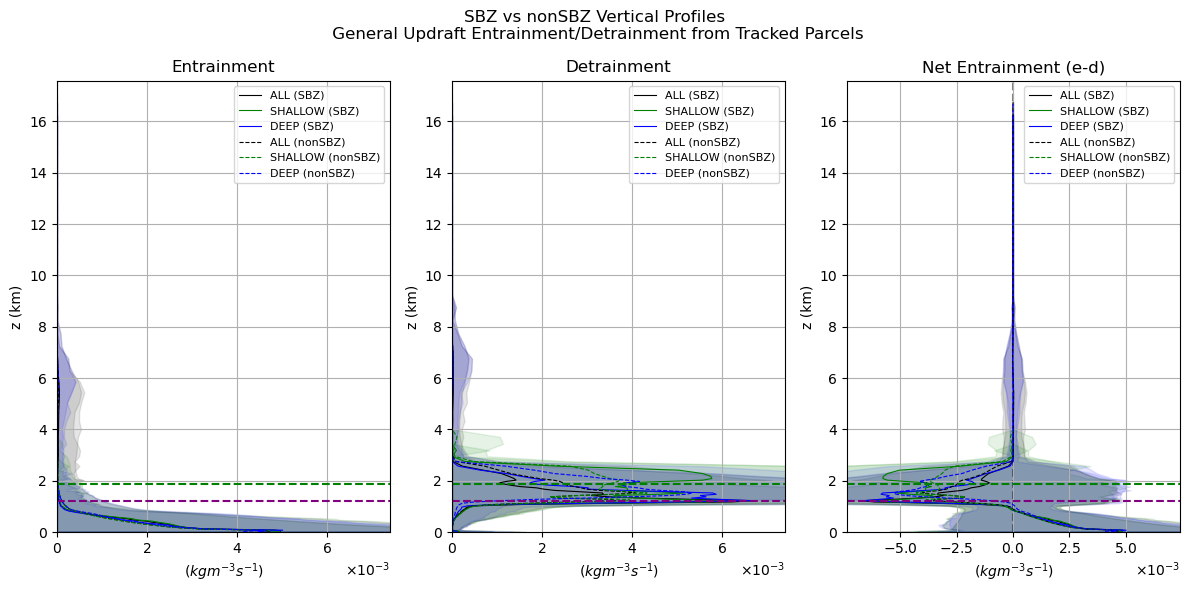

In [229]:
#PLOTTING
type4='general'
# type4='cloudy'

fig = plt.figure(figsize=(12, 6))
gs = fig.add_gridspec(1, 3)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])

# Run the plotting function separately for each axis
PlotProfiles(ax1,type1=type1,type2=type2,type3='E',type4=type4[0].upper())
PlotProfiles(ax2,type1=type1,type2=type2,type3='D',type4=type4[0].upper())
PlotProfiles(ax3,type1=type1,type2=type2,type3='NET',type4=type4[0].upper())

#LIMITING Y AXIS
if type4=='general':
    y_max=4
else:
    y_max=7
for ax in [ax1,ax2,ax3]:
    ax.set_ylim(bottom=0)
    #LIMITING YAXIS TO BELOW 7 KM
    if limit_y==True: 
        limit_axes_to_y(ax,y_min=0, y_max=y_max)    
MatchAxisLimits([ax1,ax2,ax3],dim='x')
for ax in [ax1,ax2]:
    ax.set_xlim(left=0)

# Optional: customize titles for each panel
ax1.set_title('Entrainment');ax1.set_ylim(bottom=0)
ax2.set_title('Detrainment');ax2.set_ylim(bottom=0)
ax3.set_title('Net Entrainment (e-d)');ax3.set_ylim(bottom=0)

plt.suptitle(f'{type1} vs {type2} Vertical Profiles\n {type4.title()} Updraft Entrainment/Detrainment from Tracked Parcels')
plt.tight_layout()

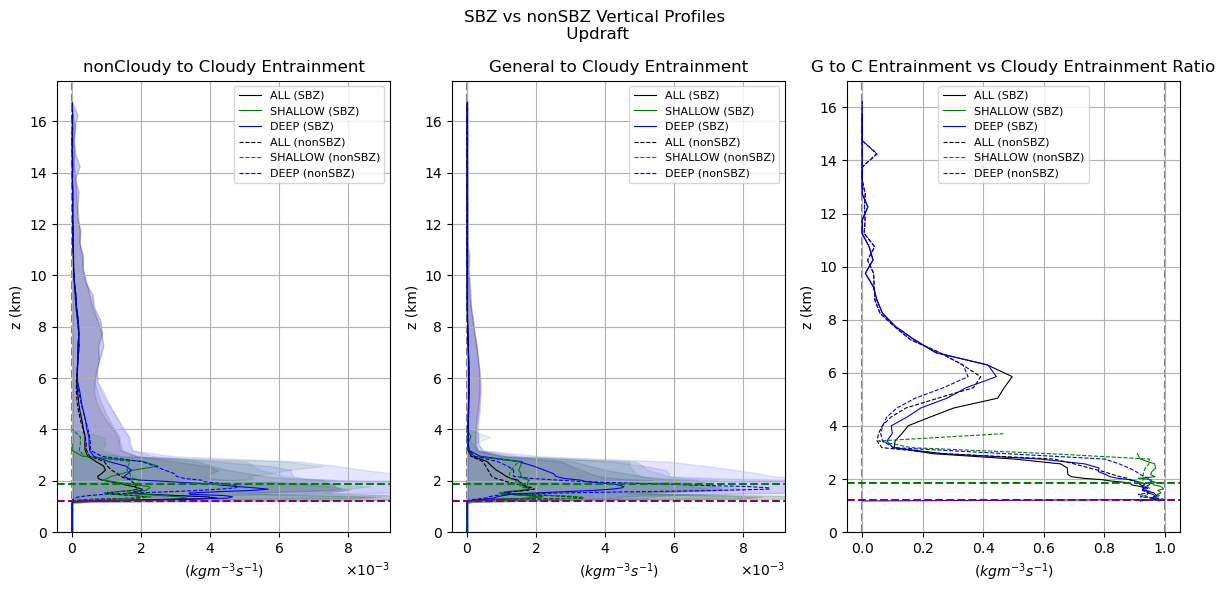

In [230]:
#PLOTTING
type4='cloudy'
fig = plt.figure(figsize=(12, 6))
gs = fig.add_gridspec(1,3)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])

# Run the plotting function separately for each axis
PlotProfiles(ax1,type1=type1,type2=type2,type3='E',type4=type4[0].upper())
PlotTwo(ax2,type1=type1,type2=type2)
RatioPlot(ax3,type1=type1,type2=type2,type3='E',type4=type4[0].upper())

#LIMITING Y AXIS
for ax in [ax1,ax2,ax3]:
    ax.set_ylim(bottom=0)
    #LIMITING YAXIS TO BELOW 7 KM
    if limit_y==True: 
        limit_axes_to_y(ax,y_min=0, y_max=7)
MatchAxisLimits([ax1,ax2],dim='x')

# Optional: customize titles for each panel
ax1.set_title('nonCloudy to Cloudy Entrainment')
ax2.set_title('General to Cloudy Entrainment')
ax3.set_title('G to C Entrainment vs Cloudy Entrainment Ratio')
plt.suptitle(f'{type1} vs {type2} Vertical Profiles\n Updraft')
plt.tight_layout()

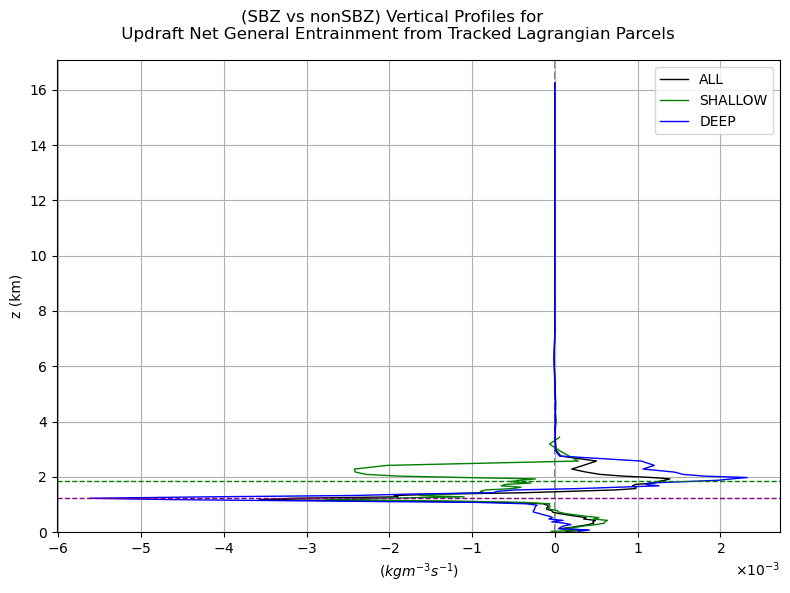

In [231]:
#DIFFERENCE PLOT
type4='general'
# type4='cloudy'

group1='SBZ';group2='nonSBZ'
PlotDifference1(group1,group2,type4)

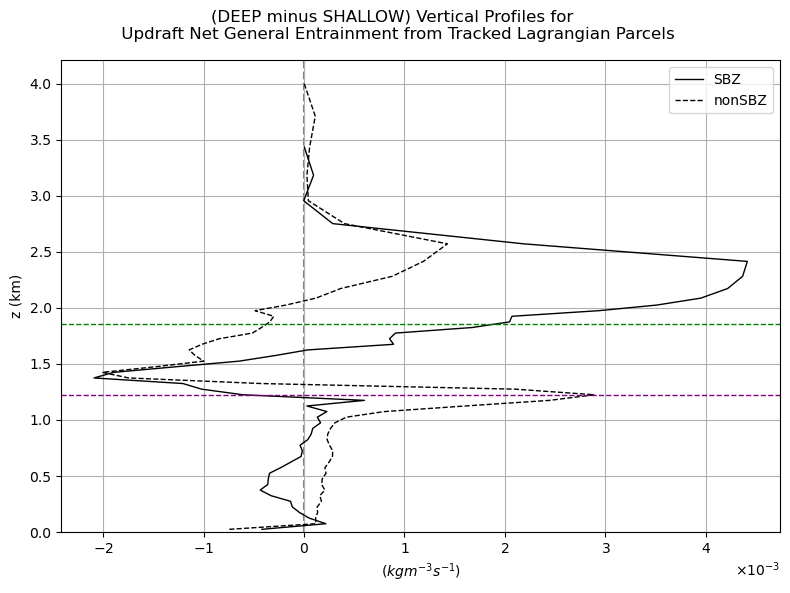

In [232]:
#DIFFERENCE PLOT
type4='general'
# type4='cloudy'

cat1='DEEP';cat2='SHALLOW'
group1='SBZ';group2='nonSBZ'
PlotDifference2(group1,group2,cat1,cat2,type4)

In [233]:
#ColdPool
################################################################

In [234]:
########################
#PLOTTING

In [235]:
data_type="Tracked_Entrainment_VMF"
type1='SBZ'
type2='ColdPool'
dir3=dir+'Project_Algorithms/Tracked_Profiles/OUTPUT_FILES/'
if PROCESSING==True:
    filePath=dir3+f"{data_type}_"+f"{type2}_tracked_profiles_{res}_{t_res}_{Np_str}.h5"
elif PROCESSING==False:
    filePath=dir3+f"{data_type}_"+f"{type2}_tracked_profiles_{res}_{t_res}_{Np_str}_ORIGINAL.h5"
key_list=[]
with h5py.File(filePath, 'r') as h5f:
    for key in h5f.keys():
        globals()[key] = h5f[key][:]
        if '_squares' not in key:
            key_list.append(key)

#CALCULATING STANDARD DEVIATION
for key in key_list:
    # globals()[key+f"_SE"]=ProfileStandardError(globals()[key],globals()[key+f"_squares"]);factor=1.96
    globals()[key+f"_SE"]=ProfileStandardDeviation(globals()[key],globals()[key+f"_squares"]); factor=1
    # print(key)

In [236]:
data_type2="Tracked_Combined_Entrainment"
type2='ColdPool'
dir3=dir+'Project_Algorithms/Tracked_Profiles/OUTPUT_FILES/'
if PROCESSING==True:
    filePath=dir3 + f"{data_type2}_" + f"{type2}_tracked_profiles_{res}_{t_res}_{Np_str}.h5"
elif PROCESSING==False:
    filePath=dir3 + f"{data_type2}_" + f"{type2}_tracked_profiles_{res}_{t_res}_{Np_str}_ORIGINAL.h5"
key_list=[]
with h5py.File(filePath, 'r') as h5f:
    for key in h5f.keys():
        globals()[key] = h5f[key][:]
        if '_squares' not in key:
            key_list.append(key)
        # print(key)

#CALCULATING STANDARD DEVIATION
for key in key_list:
    # globals()[key+f"_SE"]=ProfileStandardError(globals()[key],globals()[key+f"_squares"]);factor=1.96
    globals()[key+f"_SE"]=ProfileStandardDeviation(globals()[key],globals()[key+f"_squares"]); factor=1

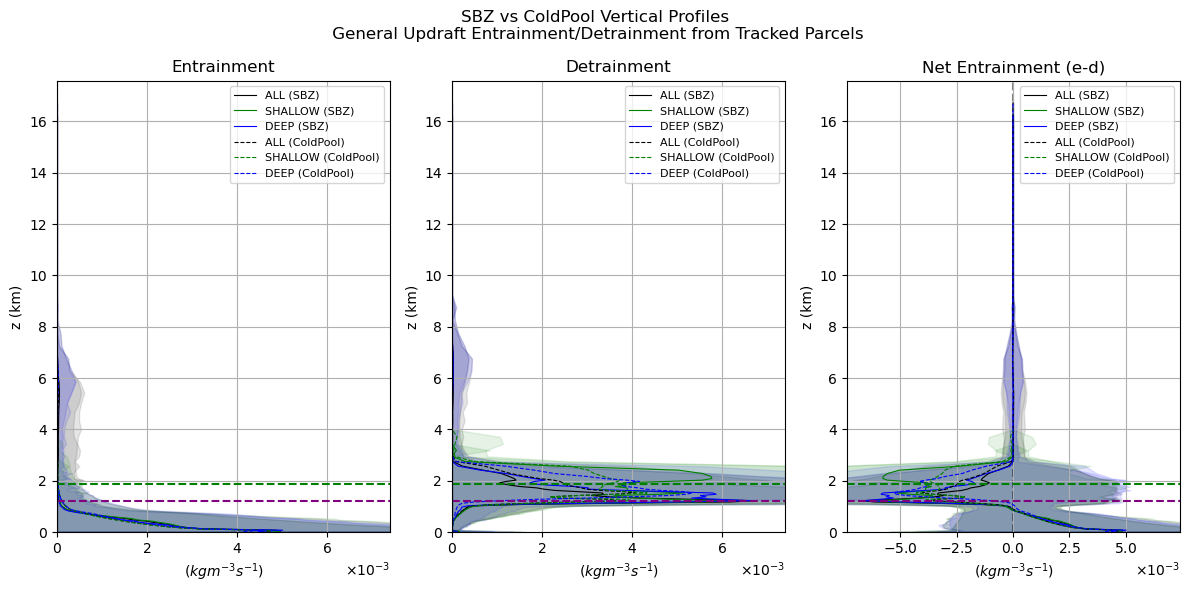

In [237]:
#PLOTTING
type4='general'
# type4='cloudy'

fig = plt.figure(figsize=(12, 6))
gs = fig.add_gridspec(1, 3)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])

# Run the plotting function separately for each axis
PlotProfiles(ax1,type1=type1,type2=type2,type3='E',type4=type4[0].upper())
PlotProfiles(ax2,type1=type1,type2=type2,type3='D',type4=type4[0].upper())
PlotProfiles(ax3,type1=type1,type2=type2,type3='NET',type4=type4[0].upper())

#LIMITING Y AXIS
if type4=='general':
    y_max=4
else:
    y_max=7
for ax in [ax1,ax2,ax3]:
    ax.set_ylim(bottom=0)
    #LIMITING YAXIS TO BELOW 7 KM
    if limit_y==True: 
        limit_axes_to_y(ax,y_min=0, y_max=y_max)    
MatchAxisLimits([ax1,ax2,ax3],dim='x')
for ax in [ax1,ax2]:
    ax.set_xlim(left=0)

# Optional: customize titles for each panel
ax1.set_title('Entrainment');ax1.set_ylim(bottom=0)
ax2.set_title('Detrainment');ax2.set_ylim(bottom=0)
ax3.set_title('Net Entrainment (e-d)');ax3.set_ylim(bottom=0)

plt.suptitle(f'{type1} vs {type2} Vertical Profiles\n {type4.title()} Updraft Entrainment/Detrainment from Tracked Parcels')
plt.tight_layout()


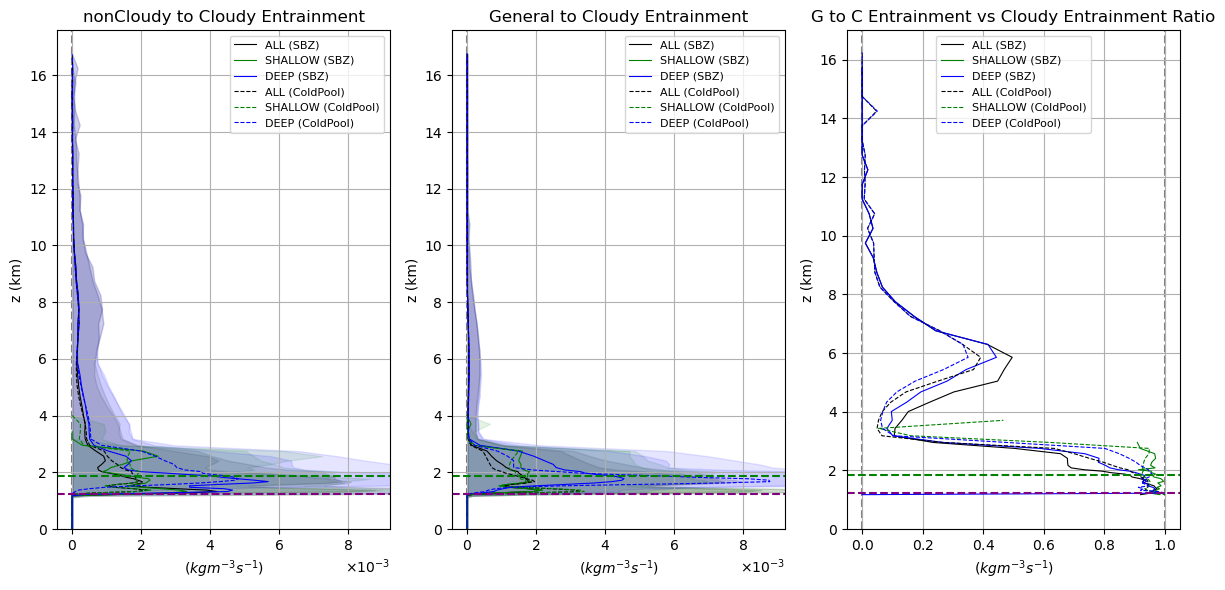

In [238]:
#PLOTTING
type4='cloudy'
fig = plt.figure(figsize=(12, 6))
gs = fig.add_gridspec(1,3)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])

# Run the plotting function separately for each axis
PlotProfiles(ax1,type1=type1,type2=type2,type3='E',type4=type4[0].upper())
PlotTwo(ax2,type1=type1,type2=type2)
RatioPlot(ax3,type1=type1,type2=type2,type3='E',type4=type4[0].upper())
for ax in [ax1,ax2,ax3]:
    ax.set_ylim(bottom=0)
    #LIMITING YAXIS TO BELOW 7 KM
    if limit_y==True: 
        limit_axes_to_y(ax,y_min=0, y_max=7)
MatchAxisLimits([ax1,ax2],dim='x')

# Optional: customize titles for each panel
ax1.set_title('nonCloudy to Cloudy Entrainment')
ax2.set_title('General to Cloudy Entrainment')
ax3.set_title('G to C Entrainment vs Cloudy Entrainment Ratio')
plt.tight_layout()

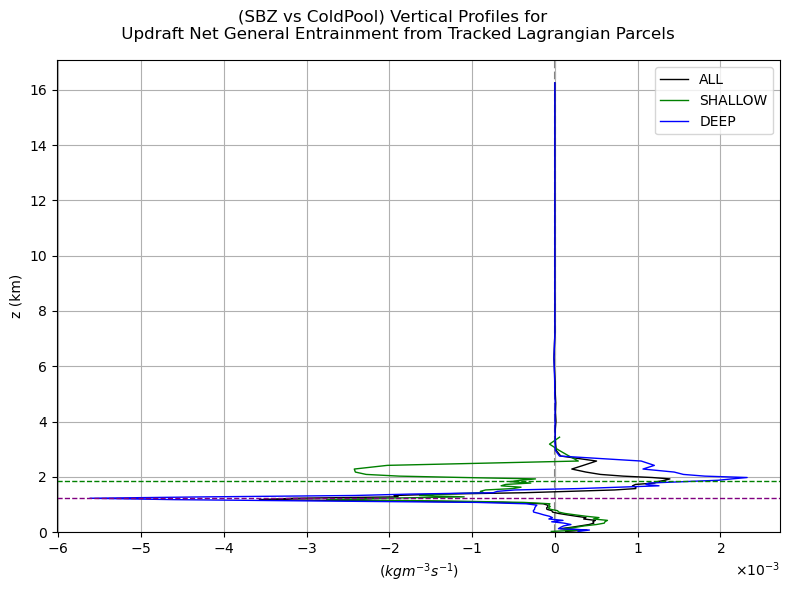

In [239]:
#DIFFERENCE PLOT
type4='general'
# type4='cloudy'

group1='SBZ';group2='ColdPool'
PlotDifference1(group1,group2,type4)

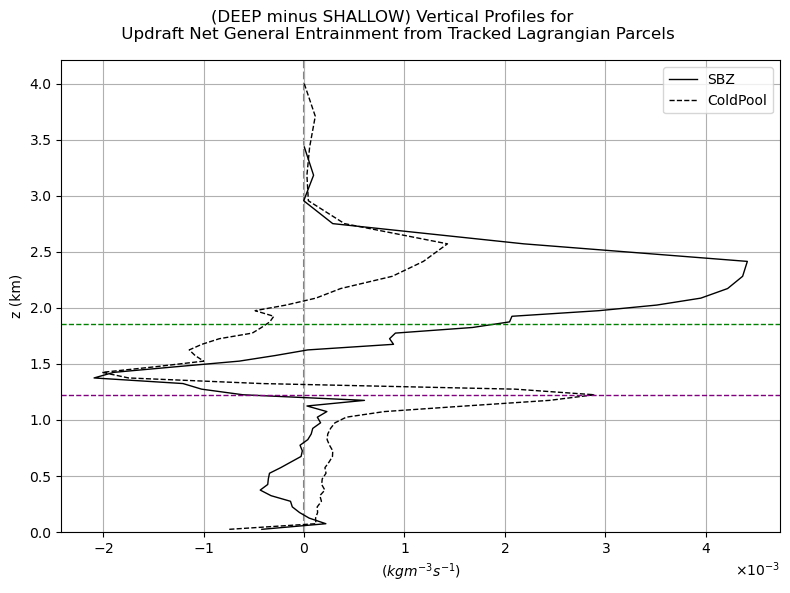

In [240]:
#DIFFERENCE PLOT
type4='general'
# type4='cloudy'

cat1='DEEP';cat2='SHALLOW'
group1='SBZ';group2='ColdPool'
PlotDifference2(group1,group2,cat1,cat2,type4)